**Лабораторная работа 3**

**Создание однонаправленной нейронной сети**

*Задан массив, состоящий из нескольких значений функции \begin{align} y = Ce^{(-\frac{(x-A)^2}{S})} \end{align} (S > 0) на интервале (0,1). Создать нейронную сеть прямого распространения, что при вводе значений функции на входы сети на выходах получались бы значения параметров C, A, S.*

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score

*Подготовка данных для обучения сети*

In [59]:
def generate_data(m=100, n=21, noise=0.0):
    x = np.linspace(0, 1, n)
    p = np.zeros((m, n))
    t = np.zeros((m, 3))

    for i in range(m):
        c = 0.9 * np.random.rand() + 0.1
        a = 0.9 * np.random.rand() + 0.1
        s = 0.9 * np.random.rand() + 0.1
        y = c * np.exp(-((x - a) ** 2) / s)
        if noise > 0:
            y += noise * np.random.randn(n)
        p[i, :] = y
        t[i, :] = [c, a, s]
    return p, t, x

*Создание сети*

In [60]:
def create_network(input_dim=21, hidden_units=(15, 10, 5)):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(hidden_units[0], activation='sigmoid'))
    for units in hidden_units[1:]:
        model.add(Dense(units, activation='tanh'))
    model.add(Dense(3, activation='linear'))
    return model

*Обучение сети*

In [61]:
def train_network(model, p_train, t_train, epochs=500, verbose=1):
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

    history = model.fit(p_train, t_train, epochs=epochs, batch_size=32, validation_split=0.2,
                        verbose=verbose, shuffle=True)
    return history

*Тестирование сети*

In [62]:
def test_network(model, p_test, t_test):
    predictions = model.predict(p_test)
    results = {}
    param_names = ['C', 'A', 'S']

    for i, name in enumerate(param_names):
        true_vals = t_test[:, i]
        pred_vals = predictions[:, i]

        r2 = r2_score(true_vals, pred_vals)
        corr = np.corrcoef(true_vals, pred_vals)[0, 1]
        mae = np.mean(np.abs(true_vals - pred_vals))
        rmse = np.sqrt(np.mean((true_vals - pred_vals) ** 2))

        results[name] = {'r2': r2, 'correlation': corr, 'mae': mae, 'rmse': rmse,
                         'true': true_vals, 'pred': pred_vals}
    return results, predictions

In [63]:
def print_params(results):
    print(f"\n{'Параметр':<10} {'R²':<12} {'Корреляция':<12} {'MAE':<10} {'RMSE':<10}")
    for param in ['C', 'A', 'S']:
        print(f"{param:<10} {results[param]['r2']:<12.4f} "
              f"{results[param]['correlation']:<12.4f} "
              f"{results[param]['mae']:<10.4f} "
              f"{results[param]['rmse']:<10.4f}")

*Визуализация*

In [64]:
def plot_results(results):
    param_names = ['C', 'A', 'S']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, (name, ax) in enumerate(zip(param_names, axes)):
        true_vals = results[name]['true']
        pred_vals = results[name]['pred']

        ax.scatter(true_vals, pred_vals, alpha=0.6, edgecolors='k', linewidth=0.5)
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеал')

        ax.set_xlabel(f'Истинный {name}')
        ax.set_ylabel(f'Предсказанный {name}')
        ax.set_title(f'{name}: R² = {results[name]["r2"]:.4f}, ρ = {results[name]["correlation"]:.4f}')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig('regression_results.png', dpi=150)
    plt.show()

In [65]:
def plot_mse_mae(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss (MSE)')
    plt.title('Кривая обучения')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Эпоха')
    plt.ylabel('MAE')
    plt.title('Средняя абсолютная ошибка')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

*Моделирование*

In [66]:
def predict_parameters(model, y_values):
    y_values = np.array(y_values).reshape(1, -1)
    prediction = model.predict(y_values)
    return {
        'C': prediction[0, 0],
        'A': prediction[0, 1],
        'S': prediction[0, 2]
    }

*Основной блок работы*

In [67]:
M_TRAIN = 500
M_TEST = 200
N = 21

Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_188 (Dense)               │ (None, 15)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_190 (Dense)               │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_191 (Dense)               │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 563 (2.20 KB)

 Trainable params: 563 (2.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3771 - mae: 0.4682 - val_loss: 0.0881 - val_mae: 0.2405
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0730 - mae: 0.2234 - val_loss: 0.0520 - val_mae: 0.1916
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0469 - mae: 0.1828 - val_loss: 0.0375 - val_mae: 0.1570
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0373 - mae: 0.1527 - val_loss: 0.0337 - val_mae: 0.1403
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0324 - mae: 0.1382 - val_loss: 0.0321 - val_mae: 0.1360
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0319 - mae: 0.1336 - val_loss: 0.0332 - val_mae: 0.1342
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0301 - mae: 0.1297 - val_loss: 0.0319 - val_mae: 0.1397
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0314 - mae: 0.1353 - val_loss: 0.0310 - val_mae: 0.1274
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.03

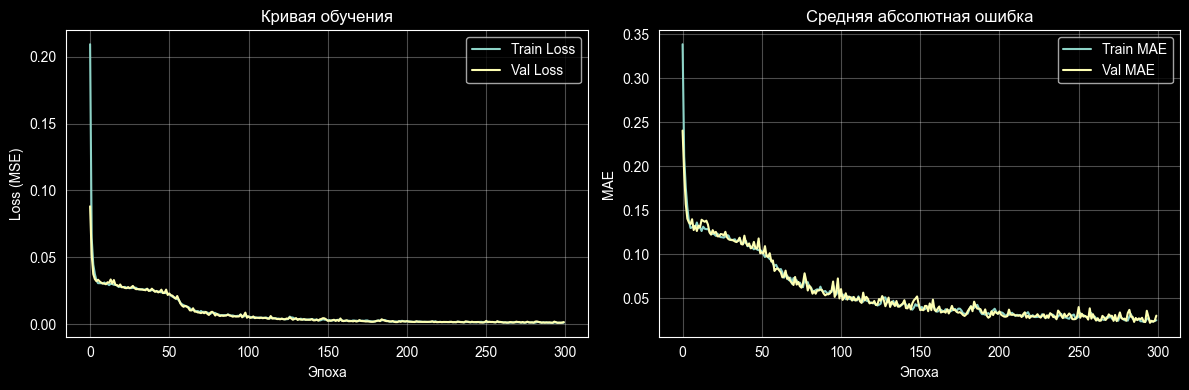

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [68]:
P_train, T_train, x = generate_data(m=M_TRAIN, n=N, noise=0.0)
P_test, T_test, _ = generate_data(m=M_TEST, n=N, noise=0.0)

model = create_network(input_dim=N, hidden_units=(15, 10, 5))
model.summary()

history = train_network(model, P_train, T_train, epochs=300, verbose=1)
plot_mse_mae(history)
results, predictions = test_network(model, P_test, T_test)


Параметр   R²           Корреляция   MAE        RMSE      
C          0.9796       0.9964       0.0340     0.0389    
A          0.9724       0.9902       0.0317     0.0447    
S          0.9858       0.9937       0.0235     0.0292    


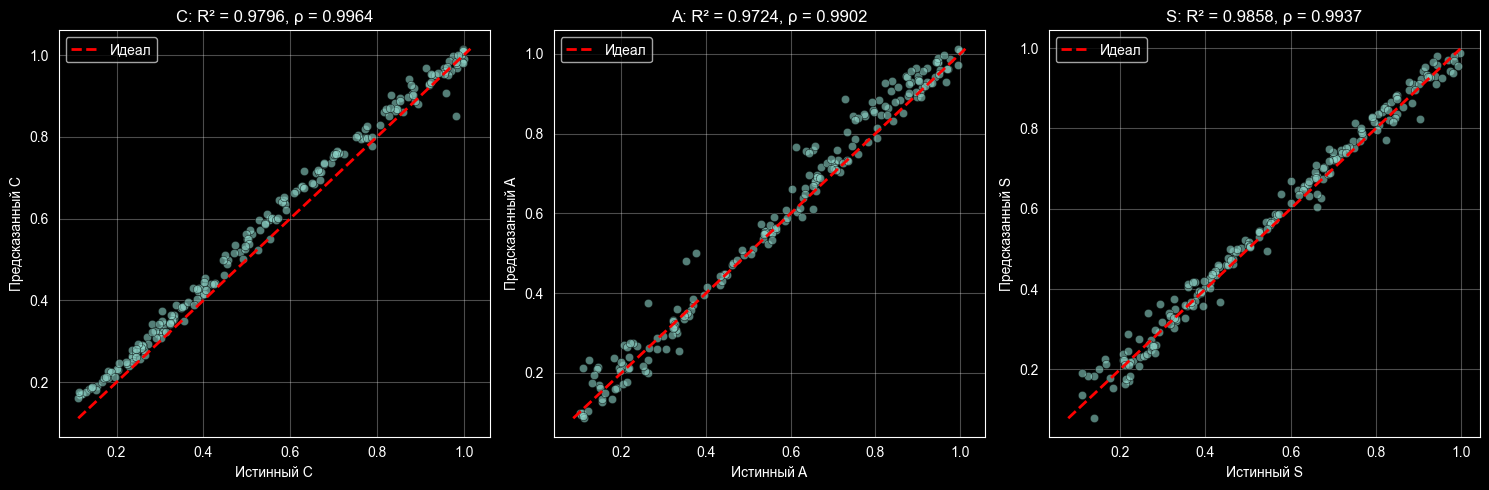

In [69]:
print_params(results)
plot_results(results)

In [70]:
test_idx = 100
pred = predict_parameters(model, P_test[test_idx])
print(f"Истинные:     C={T_test[test_idx][0]:.4f}, A={T_test[test_idx][1]:.4f}, S={T_test[test_idx][2]:.4f}")
print(f"Предсказанные: C={pred['C']:.4f}, A={pred['A']:.4f}, S={pred['S']:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Истинные:     C=0.6543, A=0.9947, S=0.8019
Предсказанные: C=0.6837, A=0.9717, S=0.7968


*Исследование влияния шума*

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Параметр   R²           Корреляция   MAE        RMSE      
C          0.9748       0.9912       0.0285     0.0398    
A          0.9778       0.9897       0.0281     0.0382    
S          0.8605       0.9746       0.0838     0.0969    
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Параметр   R²           Корреляция   MAE        RMSE      
C          0.9742       0.9890       0.0317     0.0421    
A          0.9500       0.9796       0.0403     0.0571    
S          0.8573       0.9445       0.0775     0.0987    
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Параметр   R²           Корреляция   MAE        RMSE      
C          0.9819       0.9927       0.0268     0.0348    
A          0.9473       0.9734       0.0450     0.0605    
S          0.7672       0.8977       0.0974     0.1253    
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Параметр   R²           Корреляция   MAE        RMSE      
C          0.9650       0.9867       0.0399     0.0518    
A          0.8694 

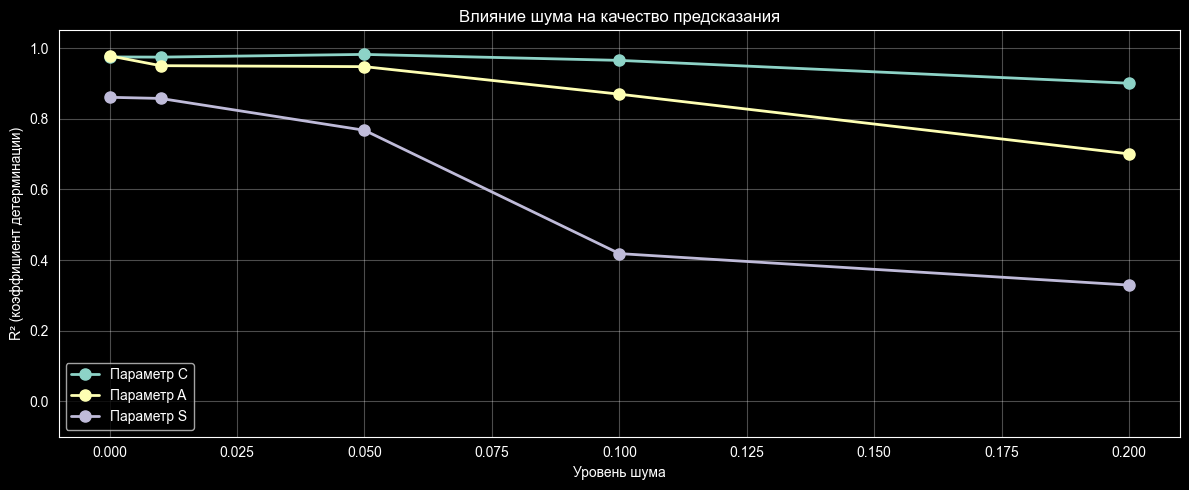

In [71]:
noise_results = {'C': [], 'A': [], 'S': []}
M_TRAIN = 500
M_TEST = 200
N = 21
EPOCHS = 150

for noise in [0, 0.01, 0.05, 0.1, 0.2]:
    P_train, T_train, _ = generate_data(m=M_TRAIN, n=N, noise=noise)
    P_test, T_test, _ = generate_data(m=M_TEST, n=N, noise=noise)

    model_noisy = create_network(input_dim=N, hidden_units=(15, 10, 5))
    history_noisy = train_network(model_noisy, P_train, T_train, epochs=EPOCHS, verbose=0)
    results_noisy, _ = test_network(model_noisy, P_test, T_test)
    for param in ['C', 'A', 'S']:
        noise_results[param].append(results_noisy[param]['r2'])

    print_params(results_noisy)

plt.figure(figsize=(12, 5))
for param in ['C', 'A', 'S']:
    plt.plot(noise_levels, noise_results[param], 'o-', linewidth=2, markersize=8, label=f'Параметр {param}')
plt.xlabel('Уровень шума')
plt.ylabel('R² (коэффициент детерминации)')
plt.title('Влияние шума на качество предсказания')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.05)

plt.tight_layout()
plt.show()

*Обучение на случайных данных*

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Параметр   R²           Корреляция   MAE        RMSE      
C          -0.0718      0.1182       0.2482     0.2965    
A          -0.0901      -0.0048      0.2637     0.3109    
S          -0.3529      -0.0150      0.2836     0.3317    


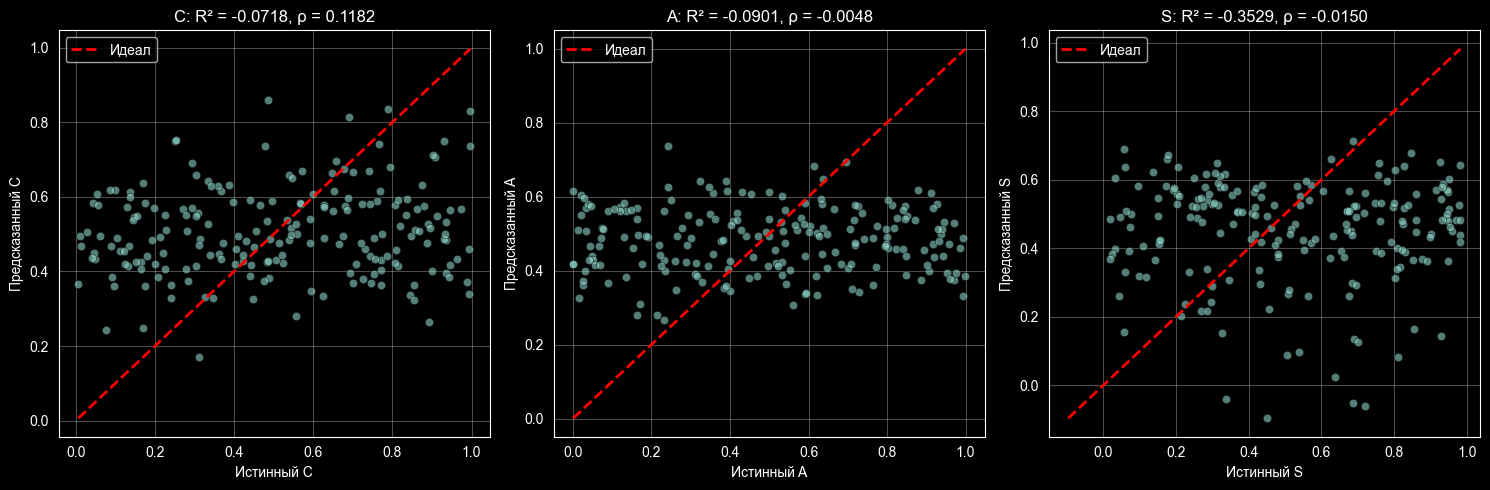

In [72]:
M_TRAIN = 500
M_TEST = 200
N = 21
EPOCHS = 150
P_random_train = np.random.rand(M_TRAIN, N)
T_random_train = np.random.rand(M_TRAIN, 3)
P_random_test = np.random.rand(M_TEST, N)
T_random_test = np.random.rand(M_TEST, 3)

model_random = create_network(input_dim=N, hidden_units=(15, 10, 5))
history_random = train_network(model_random, P_random_train, T_random_train, epochs=EPOCHS, verbose=0)
results_random, predictions_random = test_network(model_random, P_random_test, T_random_test)

print_params(results_random)

plot_results(results_random)
plt.show()